In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
#BASE_DIR = "./DATOS_RAW"  # si corres el notebook en el mismo nivel, déjalo así
# Ejemplo Windows absoluto:
BASE_DIR = r"C:\Users\Victoria\Desktop\data\datos_raw"

# Carpetas esperadas y el csv dentro de cada una
DATASETS = {
    "APTOS 2019": os.path.join(BASE_DIR, "aptos_2019", "train.csv"),
    "EyePACS":    os.path.join(BASE_DIR, "eyePACS", "train.csv"),
    "IDRiD":      os.path.join(BASE_DIR, "idrid", "train.csv"),
    "Messidor":   os.path.join(BASE_DIR, "messidor", "train.csv"),
}

# Orden de clases y etiquetas
CLASS_ORDER = [0, 1, 2, 3, 4]
CLASS_LABELS = {
    0: "No RD",
    1: "Leve",
    2: "Moderado",
    3: "Severo",
    4: "PRD",
}

# Posibles nombres de columna para clase y para id de imagen
POSSIBLE_LEVEL_COLS = ["level", "diagnosis", "grade", "severity", "dr_grade", "retinopathy_grade"]
POSSIBLE_IMAGE_COLS = ["image", "image_id", "id_code", "filename", "img", "file"]

def find_col(df, candidates):
    """Devuelve el primer nombre de columna que exista en df."""
    for c in candidates:
        if c in df.columns:
            return c
    return None


In [4]:
import os
print("📍 Working directory actual:")
print(os.getcwd())

print("\n📂 Contenido del working directory:")
print(os.listdir())

📍 Working directory actual:
c:\Users\Victoria\Desktop\data\datos_raw

📂 Contenido del working directory:
['.ipynb_checkpoints', 'aptos_2019', 'cache_arrays', 'data', 'entrenamiento DL prueba.ipynb', 'entrenamiento DL.ipynb', 'entrenamiento_1.ipynb', 'entrenamiento_2.ipynb', 'entrenamiento_DL_efficientnet_b0.ipynb', 'entrenamiento_DL_efficientnet_b0_ordinal_mixup_plateau.ipynb', 'entrenamiento_ML_combined.ipynb', 'entrenamiento_ML_combined_qwk.ipynb', 'eyePACS', 'idrid', 'messidor', 'ML_NOTEBOOK_README.md', 'resultados_dl', 'resultados_ml', 'resultados_ml_features', 'resultados_ml_raw']


In [3]:
rows = []
errors = []

for ds_name, csv_path in DATASETS.items():
    if not os.path.exists(csv_path):
        errors.append(f"❌ No existe: {csv_path}")
        continue

    df = pd.read_csv(csv_path)

    level_col = find_col(df, POSSIBLE_LEVEL_COLS)
    if level_col is None:
        errors.append(f"❌ {ds_name}: no encuentro columna de nivel. Columnas: {list(df.columns)}")
        continue

    # Asegurar numérico (por si viene como string)
    df[level_col] = pd.to_numeric(df[level_col], errors="coerce")

    # Conteo por clase (0..4)
    counts = df[level_col].value_counts(dropna=False).to_dict()

    for k in CLASS_ORDER:
        n = int(counts.get(k, 0))
        rows.append({"dataset": ds_name, "nivel": CLASS_LABELS[k], "n": n})

# Mostrar errores si hubo
if errors:
    print("\n".join(errors))

df_counts = pd.DataFrame(rows)

In [4]:
niveles_orden = ["No RD", "Leve", "Moderado", "Severo", "PRD"]
df_counts["nivel"] = pd.Categorical(df_counts["nivel"], categories=niveles_orden, ordered=True)

pivot = df_counts.pivot_table(index="nivel", columns="dataset", values="n", aggfunc="sum").fillna(0)

print("✅ Conteos por dataset y clase:")
display(pivot)

✅ Conteos por dataset y clase:


C:\Users\Victoria\AppData\Local\Temp\ipykernel_3812\4111720268.py:4: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df_counts.pivot_table(index="nivel", columns="dataset", values="n", aggfunc="sum").fillna(0)


dataset,APTOS 2019,EyePACS,IDRiD,Messidor
nivel,,,,
No RD,1434,25810,134,468
Leve,300,2443,20,202
Moderado,808,5292,136,284
Severo,154,873,74,71
PRD,234,708,49,21


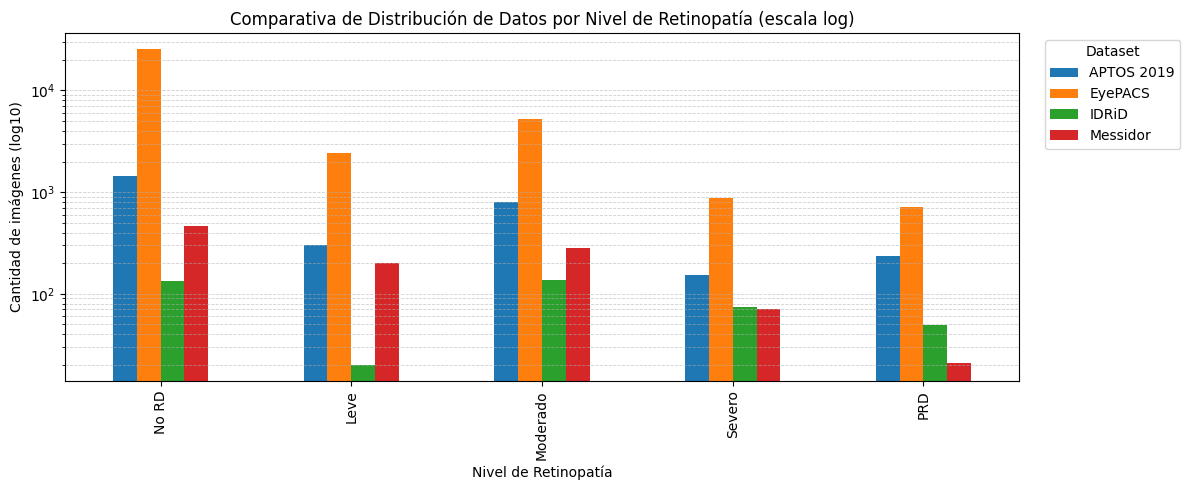

In [5]:
ax = pivot.plot(kind="bar", figsize=(12, 5))

ax.set_title("Comparativa de Distribución de Datos por Nivel de Retinopatía (escala log)")
ax.set_xlabel("Nivel de Retinopatía")
ax.set_ylabel("Cantidad de imágenes (log10)")
ax.set_yscale("log")  # ✅ aquí está la opción 1

ax.grid(True, which="both", axis="y", linestyle="--", linewidth=0.6, alpha=0.6)
ax.legend(title="Dataset", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()